In [1]:
import pandas as pd
import numpy as np
import time
from time import time as t

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers

2026-04-08 08:52:59.487240: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775638379.781659      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775638379.867691      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775638380.578847      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775638380.578918      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775638380.578922      55 computation_placer.cc:177] computation placer alr

In [2]:
df = pd.read_csv('/kaggle/input/datasets/ayushpandey975/tweets/Tweets.csv')

# Select correct columns
df = df[['text', 'sentiment']]

# Rename for compatibility
df.rename(columns={'sentiment': 'airline_sentiment'}, inplace=True)

df.head()

,text,airline_sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


In [3]:
# Handle missing values
df = df.dropna(subset=['text'])

# Convert to string
df['text'] = df['text'].astype(str)

# Encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['airline_sentiment'])

# Tokenization
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['text'])

sequences = tokenizer.texts_to_sequences(df['text'])
X = pad_sequences(sequences, maxlen=100)

y = df['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data ready ")

Data ready 


In [4]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

In [5]:
rnn_model = Sequential([
    Embedding(5000, 64, input_length=100),
    SimpleRNN(64),
    Dense(32, activation='relu',
          kernel_regularizer=regularizers.l2(0.001)),
    Dense(3, activation='softmax')
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-04-08 08:56:30.291832: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [6]:
lstm_model = Sequential([
    Embedding(5000, 64, input_length=100),
    LSTM(64),
    Dense(32, activation='relu',
          kernel_regularizer=regularizers.l2(0.001)),
    Dense(3, activation='softmax')
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [11]:
from tensorflow.keras.layers import Embedding, GRU, Dense

In [12]:
gru_model = Sequential([
    Embedding(5000, 64, input_length=100),
    GRU(64),
    Dense(32, activation='relu',
          kernel_regularizer=regularizers.l2(0.001)),
    Dense(3, activation='softmax')
])

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [13]:
start = t()
history_gru = gru_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)
end = t()
gru_time = end - start
print("GRU Training Time:", gru_time)

Epoch 1/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 22s 68ms/step - accuracy: 0.4774 - loss: 1.0335 - val_accuracy: 0.6675 - val_loss: 0.7680 - learning_rate: 0.0010
Epoch 2/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 19s 68ms/step - accuracy: 0.7460 - loss: 0.6383 - val_accuracy: 0.6889 - val_loss: 0.7298 - learning_rate: 0.0010
Epoch 3/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - accuracy: 0.7883 - loss: 0.5406 - val_accuracy: 0.6912 - val_loss: 0.7409 - learning_rate: 0.0010
Epoch 4/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 19s 68ms/step - accuracy: 0.8272 - loss: 0.4559 - val_accuracy: 0.6982 - val_loss: 0.7865 - learning_rate: 5.0000e-04
GRU Training Time: 77.9713978767395


In [7]:
start_time = time.time()

history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

end_time = time.time()
rnn_time = end_time - start_time

print("RNN Training Time:", rnn_time)

Epoch 1/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.4246 - loss: 1.0886 - val_accuracy: 0.6222 - val_loss: 0.8659 - learning_rate: 0.0010
Epoch 2/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.7130 - loss: 0.7008 - val_accuracy: 0.6502 - val_loss: 0.8432 - learning_rate: 0.0010
Epoch 3/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.8591 - loss: 0.4152 - val_accuracy: 0.6432 - val_loss: 0.9632 - learning_rate: 0.0010
Epoch 4/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.9417 - loss: 0.2153 - val_accuracy: 0.6268 - val_loss: 1.2111 - learning_rate: 5.0000e-04
RNN Training Time: 30.55042600631714


In [8]:
start = t()

history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

end = t()
lstm_time = end - start

print("LSTM Training Time:", lstm_time)

Epoch 1/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.4763 - loss: 1.0295 - val_accuracy: 0.6761 - val_loss: 0.7636 - learning_rate: 0.0010
Epoch 2/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 16s 60ms/step - accuracy: 0.7357 - loss: 0.6527 - val_accuracy: 0.6905 - val_loss: 0.7335 - learning_rate: 0.0010
Epoch 3/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - accuracy: 0.7867 - loss: 0.5534 - val_accuracy: 0.7005 - val_loss: 0.7432 - learning_rate: 0.0010
Epoch 4/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - accuracy: 0.8240 - loss: 0.4806 - val_accuracy: 0.6957 - val_loss: 0.7830 - learning_rate: 5.0000e-04
LSTM Training Time: 68.40844798088074


In [14]:
rnn_loss, rnn_acc = rnn_model.evaluate(X_test, y_test, verbose=0)
lstm_loss, lstm_acc = lstm_model.evaluate(X_test, y_test, verbose=0)
gru_loss, gru_acc = gru_model.evaluate(X_test, y_test, verbose=0)

print("\n===== FINAL RESULTS =====")
print(f"RNN  Accuracy: {rnn_acc:.4f}")
print(f"LSTM Accuracy: {lstm_acc:.4f}")
print(f"GRU  Accuracy: {gru_acc:.4f}")
print(f"RNN  Time: {rnn_time:.2f} sec")
print(f"LSTM Time: {lstm_time:.2f} sec")
print(f"GRU  Time: {gru_time:.2f} sec")
print(f"LSTM vs RNN  Improvement: {(lstm_acc - rnn_acc)*100:.2f}%")
print(f"GRU  vs RNN  Improvement: {(gru_acc - rnn_acc)*100:.2f}%")
print(f"GRU  vs LSTM Improvement: {(gru_acc - lstm_acc)*100:.2f}%")


===== FINAL RESULTS =====
RNN  Accuracy: 0.6554
LSTM Accuracy: 0.6940
GRU  Accuracy: 0.6972
RNN  Time: 30.55 sec
LSTM Time: 68.41 sec
GRU  Time: 77.97 sec
LSTM vs RNN  Improvement: 3.86%
GRU  vs RNN  Improvement: 4.18%
GRU  vs LSTM Improvement: 0.33%


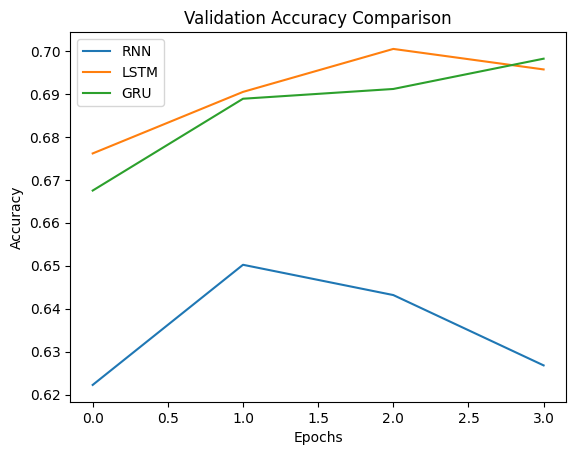

In [15]:
import matplotlib.pyplot as plt

plt.plot(history_rnn.history['val_accuracy'], label='RNN')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM')
plt.plot(history_gru.history['val_accuracy'], label='GRU')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()